In [6]:
pip install shutil

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement shutil (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for shutil


In [12]:
import pandas as pd
import kagglehub
import os
import shutil
import numpy as np
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

In [45]:
df = pd.read_csv("./dataset/fitness.csv")
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,54.0,Male,88.5,2.00,173,134.0,58.0,1.11,1388.0,HIIT,27.7,3.7,3.0,2.0,36.73
1796,52.0,Male,84.3,1.69,164,169.0,54.0,0.77,1367.0,HIIT,32.6,2.9,3.0,2.0,15.11
1797,47.0,Male,70.1,1.84,188,129.0,67.0,1.20,1261.0,Strength,28.4,2.5,3.0,2.0,17.99
1798,35.0,Male,49.3,1.71,180,152.0,73.0,1.04,956.0,Cardio,32.9,1.7,4.0,3.0,12.65


In [18]:
data = {"car":["BMW","PAGANI","MERCEDES"],"count":[1,3,0]}
df = pd.DataFrame(data)
df

,car,count
0,BMW,1
1,PAGANI,3
2,MERCEDES,0


In [30]:
data_s = [1,2,3,4]
series = pd.Series(data_s)
print(series[2])

3


In [31]:
series = pd.Series(data_s,index=["p","q","r","s"])
print(series["r"])

3


In [34]:
dictionary = {
    "day1" :300,
    "day2" :320,
    "day3" :400,
}
series = pd.Series(dictionary,index = ["day1","day2"])
series

day1    300
day2    320
dtype: int64

In [42]:
data = {
    "calories" : [420,380,390],
    "duration" : [50,40,45]
}

df = pd.DataFrame(data)
df.loc[[0,1]]

,calories,duration
0,420,50
1,380,40


In [44]:
df = pd.DataFrame(data,index = ["day1","day2","day3"])
df.loc["day1"]

calories    420
duration     50
Name: day1, dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1790 non-null   float64
 1   Gender                         1729 non-null   object 
 2   Weight (kg)                    1778 non-null   float64
 3   Height (m)                     1774 non-null   float64
 4   Max_BPM                        1779 non-null   object 
 5   Avg_BPM                        1770 non-null   float64
 6   Resting_BPM                    1781 non-null   float64
 7   Session_Duration (hours)       1777 non-null   float64
 8   Calories_Burned                1777 non-null   float64
 9   Workout_Type                   1739 non-null   object 
 10  Fat_Percentage                 1784 non-null   float64
 11  Water_Intake (liters)          1776 non-null   float64
 12  Workout_Frequency (days/week)  1742 non-null   f

## Data Cleaning

In [21]:
df = pd.read_csv("./dataset/data.csv")
print(df)

    Duration        Date  Pulse  Maxpulse  Calories
0         60  2020/12/01    110       130     409.1
1         60  2020/12/02    117       145     479.0
2         60  2020/12/03    103       135     340.0
3         45  2020/12/04    109       175     282.4
4         45  2020/12/05    117       148     406.0
5         60  2020/12/06    102       127     300.0
6         60  2020/12/07    110       136     374.0
7        450  2020/12/08    104       129     253.3
8         30  2020/12/09    109       133     195.1
9         60  2020/12/10     98       124     269.0
10        60  2020/12/11    103       147     329.3
11        60  2020/12/12    100       120     250.7
12        60  2020/12/12    100       120     250.7
13        60  2020/12/13    106       128     345.3
14        45  2020/12/14    104       132     379.3
15        60  2020/12/15     98       123     275.0
16        60  2020/12/16    100       120     215.2
17        60  2020/12/17    100       120     300.0
18        60

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


In [42]:
drop_na = df.dropna()
drop_na

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.1
1,60,2020-12-02,117,145,479.0
2,60,2020-12-03,103,135,340.0
3,45,2020-12-04,109,175,282.4
4,45,2020-12-05,117,148,406.0
5,60,2020-12-06,102,127,300.0
6,60,2020-12-07,110,136,374.0
7,450,2020-12-08,104,129,253.3
8,30,2020-12-09,109,133,195.1
9,60,2020-12-10,98,124,269.0


In [33]:
df.fillna({"Calories":130},inplace=True)
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01,110,130,409.1
1,60,2020/12/02,117,145,479.0
2,60,2020/12/03,103,135,340.0
3,45,2020/12/04,109,175,282.4
4,45,2020/12/05,117,148,406.0
5,60,2020/12/06,102,127,300.0
6,60,2020/12/07,110,136,374.0
7,450,2020/12/08,104,129,253.3
8,30,2020/12/09,109,133,195.1
9,60,2020/12/10,98,124,269.0


In [24]:
df["Date"] = pd.to_datetime(df["Date"],format = 'mixed')

In [25]:
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,450,2020-12-08,104,129,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00


In [48]:
for x in df.index:
    if df.loc[x,"Duration"] > 120:
        df.loc[x,"Duration"] = 120
df

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.1
1,60,2020-12-02,117,145,479.0
2,60,2020-12-03,103,135,340.0
3,45,2020-12-04,109,175,282.4
4,45,2020-12-05,117,148,406.0
5,60,2020-12-06,102,127,300.0
6,60,2020-12-07,110,136,374.0
7,120,2020-12-08,104,129,253.3
8,30,2020-12-09,109,133,195.1
9,60,2020-12-10,98,124,269.0


In [26]:
x = df["Calories"].mean()
df.fillna({"Calories":x},inplace = True)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  32 non-null     int64         
 1   Date      31 non-null     datetime64[ns]
 2   Pulse     32 non-null     int64         
 3   Maxpulse  32 non-null     int64         
 4   Calories  32 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 1.4 KB


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,450,2020-12-08,104,129,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00


In [27]:
df.dropna(inplace=True)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Duration  31 non-null     int64         
 1   Date      31 non-null     datetime64[ns]
 2   Pulse     31 non-null     int64         
 3   Maxpulse  31 non-null     int64         
 4   Calories  31 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 1.5 KB


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020-12-01,110,130,409.10
1,60,2020-12-02,117,145,479.00
2,60,2020-12-03,103,135,340.00
3,45,2020-12-04,109,175,282.40
4,45,2020-12-05,117,148,406.00
5,60,2020-12-06,102,127,300.00
6,60,2020-12-07,110,136,374.00
7,450,2020-12-08,104,129,253.30
8,30,2020-12-09,109,133,195.10
9,60,2020-12-10,98,124,269.00


In [10]:
df.describe()

,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,67.968750,102.968750,129.343750,305.350000
std,70.251385,5.738857,12.033848,66.560658
min,30.000000,92.000000,112.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,128.500000,291.200000
75%,60.000000,105.250000,132.250000,343.975000
max,450.000000,117.000000,175.000000,479.000000


<Axes: >

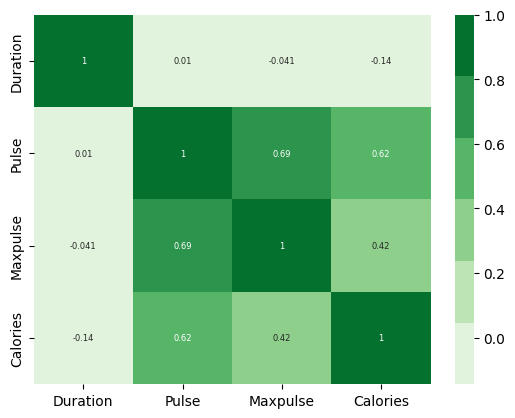

In [13]:
sns.heatmap(df.corr(numeric_only = True), cmap=sns.color_palette("Greens"), annot=True,annot_kws={"size":6})

In [15]:
test_data = {"key":["1","2","3","4","5","6","7","8","9","10"],
             "Double":["2","4","6","8","10","12","14","16","18","20"]
             }

        key  Double
key     1.0     1.0
Double  1.0     1.0


<Axes: >

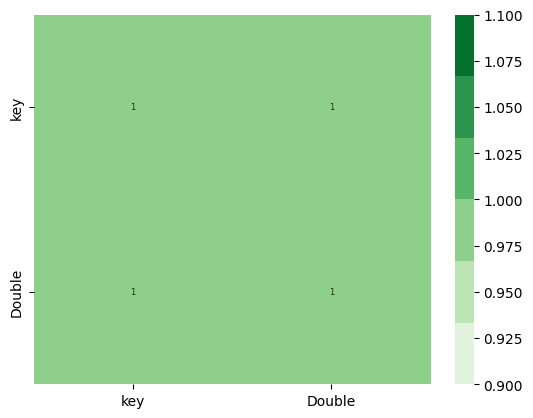

In [20]:
test_df = pd.DataFrame(test_data)
test_corr = test_df.corr()
print(test_corr)
sns.heatmap(test_corr,cmap=sns.color_palette("Greens"),annot=True,annot_kws={"size":6})

<Axes: >

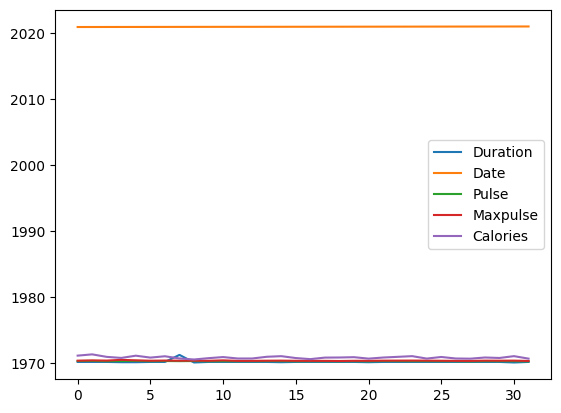

In [28]:
df.plot()